In [1]:
%load_ext autoreload
%autoreload 2
import util
import logging
import numpy as np
import matplotlib.pyplot as plt
import plotting as plotting
import experiment_1

figures_path = "../figures/ION2024/"
cache_path = "cache/"

logging.basicConfig(level=logging.INFO)
# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib widget

# Hyperparameter Search

In [5]:
config = {
    "date": "2022-02-01T00:00:00",
    "duration_factor": 0.40,
    "solver_seed": 0,
    # "RB": {},
    # "FS": {
    #     "d": [1, 2, 3],
    #     "gamma": [0.8, 0.9, 0.99, 1.0],
    #     "N_max": [2, 5, 10],
    #     "d_min": [0.5, 1, 2, 5],
    # },
    # "MCTS": {
    #     "d": [1, 2, 3],
    #     "gamma": [0.8, 0.9, 0.99, 1.0],
    #     "d_min": [0.5, 1, 2, 5],
    #     "N_max": [5, 10],
    #     #
    #     "n": [5, 10, 50],
    #     "c": [0.1, 1, 10],
    # },
    "IP": {
        "time_step_factor": [10],
    },
}
results_all = experiment_1.solve_problem(config, n_jobs=1)

IP:   0%|          | 0/2 [00:00<?, ?it/s]

AssertionError: 

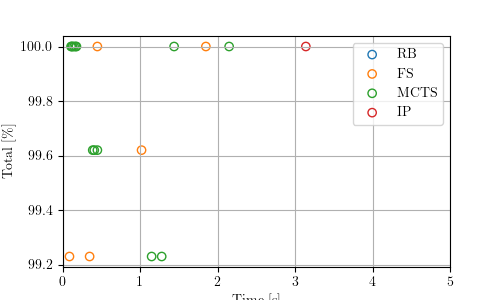

In [ ]:
plt.figure(figsize=(5, 3))
for i, solver in enumerate(["RB", "FS", "MCTS", "IP"]):
    results = results_all[solver]
    total = [r["total"] for r in results if r["total"] > 99]
    time = [r["time"] for r in results if r["total"] > 99]
    plt.scatter(
        time,
        total,
        label=solver,
        marker="o",
        facecolor="None",
        edgecolor=util.TABLEAU_COLORS[i],
    )
plt.xlabel("Time [s]")
plt.ylabel("Total [\\%]")
plt.xlim([0, 5])
plt.grid()
plt.legend()
plt.show()

In [5]:
import plotly.express as px
import pandas as pd

for solver in ["FS", "MCTS", "IP"]:
    df_dict = []
    for r in results_all[solver]:
        tmp = r["params"].copy()
        tmp["total"] = r["total"]
        tmp["time"] = r["time"]
        df_dict.append(tmp)
    df = pd.DataFrame(df_dict)

    fig = px.parallel_coordinates(df, color="total")
    fig.show()

    # Correlation of parameters to total
    correlation = df.corr()
    print(f"\n********** {solver} **********")
    print("\nHyperparameters correlation")
    print(correlation["total"].sort_values())

    # Best parameters
    print("\nBest parameters")
    print(df[df["total"] == df["total"].max()])


********** FS **********

Hyperparameters correlation
N_max   -0.230202
gamma   -0.146384
d_min    0.053344
time     0.170882
d        0.453614
total    1.000000
Name: total, dtype: float64

Best parameters
   d  gamma  N_max  d_min  total  time
0  3   0.99      5    0.5  100.0  0.45
1  3   0.90     10    1.0  100.0  1.85



********** MCTS **********

Hyperparameters correlation
N_max   -0.268849
n       -0.204535
gamma   -0.202371
time     0.015939
c        0.023715
d_min    0.127930
d        0.252400
total    1.000000
Name: total, dtype: float64

Best parameters
   d  gamma  d_min  N_max   n     c  total  time
0  3    0.8    1.0     10   5   1.0  100.0  0.11
1  3    0.8    1.0     10   5   0.1  100.0  0.12
2  3    0.8    1.0     10   5  10.0  100.0  0.13
3  2    0.8    0.5     10   5  10.0  100.0  0.15
4  2    0.8    0.5     10   5   1.0  100.0  0.17
5  2    0.8    0.5     10   5   0.1  100.0  0.18
6  3    0.8    0.5      5  50   1.0  100.0  1.44
7  3    0.9    0.5     10  50  10.0  100.0  2.15



********** IP **********

Hyperparameters correlation
time_step_factor   -0.995609
time                0.951960
total               1.000000
Name: total, dtype: float64

Best parameters
   time_step_factor  total  time
0                 4  100.0  3.14


# Monte-Carlo Sims

In [2]:
base_config = {
    "date": "2022-{month:02d}-01T00:00:00",
    "duration_factor": None,
    "solver_seed": 0,
    "RB": {},
    "FS": {
        "d": [1, 2, 3],
        "gamma": [0.7, 0.8, 0.9, 0.99],
        "N_max": [5, 10],
        "d_min": [0.5, 1, 2],
    },
    "MCTS": {
        "d": [1, 2, 3],
        "gamma": [0.7, 0.8, 0.9, 0.99],
        "d_min": [0.5, 1, 2],
        "n": [5, 10, 50],
        "c": [0.1, 1, 10],
        "N_max": [5, 10],
    },
    "IP": {
        "time_step_factor": [2, 3, 4, 5, 10],
    },
}

In [4]:
months = np.arange(1, 11)
duration_factor = 0.40
results = list[dict]() # List of results for each month
for month in months:
    print(f"Month: {month}")
    config = base_config.copy()
    config["date"] = config["date"].format(month=month)
    config["duration_factor"] = duration_factor
    results.append(experiment_1.solve_problem(config, n_jobs=1))

Month: 1
Month: 2


IP:   0%|          | 0/5 [00:00<?, ?it/s]

AssertionError: 

In [ ]:
postproc_results = {}
for solver in ["RB", "FS", "MCTS", "IP"]:
    postproc_results[solver] = dict[dict]()

    # Collect all results for the solver
    results_solver = list[dict]()
    for i in range(len(months)):
        results_solver.extend(results[i][solver])

    for r in results_solver:
        # r = {params, total, time, ...}
        params = str(r["params"])
        if params not in postproc_results[solver]:
            postproc_results[solver][params] = {key: [] for key in r.keys() if key != "params"}
        
        for key, val in r.items():
            if key == "params":
                continue
            postproc_results[solver][params][key].append(val)

In [17]:
mean_total = {}
for solver in ["RB", "FS", "MCTS", "IP"]:
    mean_total[solver] = round(max([np.mean(r["total"]) for r in postproc_results[solver].values()]),2)
print(mean_total)

{'RB': 84.09, 'FS': 98.84, 'MCTS': 100.0, 'IP': 100.0}


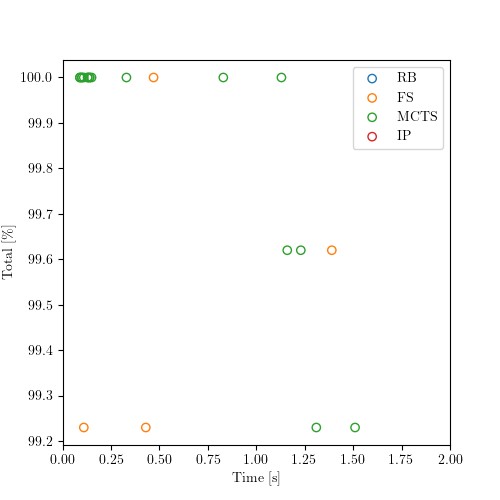

In [43]:
plt.figure(figsize=(5, 5))
for i, key in enumerate(["RB", "FS", "MCTS", "IP"]):
    results = results_all[key]
    total = [r["total"] for r in results if r["total"] > 99]
    time = [r["time"] for r in results if r["total"] > 99]
    plt.scatter(
        time,
        total,
        label=key,
        marker="o",
        facecolor="None",
        edgecolor=util.TABLEAU_COLORS[i],
    )
plt.xlabel("Time [s]")
plt.ylabel("Total [\\%]")
plt.xlim([0, 2])
plt.legend()
plt.show()